In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from huggingface_hub import hf_hub_download, snapshot_download
import pandas as pd
import os

dataset_dir = snapshot_download(
    repo_id="radiata-ai/brain-structure",
    repo_type="dataset",
    cache_dir="/content/drive/MyDrive/brain_structure_cache"
)

metadata = pd.read_csv(os.path.join(dataset_dir, "metadata.csv"))
print("Done! Samples:", len(metadata))

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import os

sample = metadata.iloc[0]
age = sample["age"]
print("Age:", age)

nii_path = os.path.join(dataset_dir, sample["t1_local_path"])
img = nib.load(nii_path)
data = img.get_fdata()

slice_img = data[:, :, data.shape[2] // 2]
plt.imshow(slice_img, cmap="gray")
plt.axis("off")
plt.show()

##Slicing & Normalizing & Resizing dataset from 3D to 2D

In [ ]:
import nibabel as nib
import numpy as np
import cv2
import os
import pandas as pd

# ── LOAD FULL METADATA ───────────────────────────────────
# Use ALL rows — train + validation + test from original splits
# We will make our own splits later with sklearn
# This gives us 3794 samples instead of only 3066
metadata_path = "/content/drive/MyDrive/brain_structure_cache/datasets--radiata-ai--brain-structure/snapshots/aea73e2a9734955407eb8bcf2325b479a5f39144/metadata.csv"
dataset_dir   = os.path.dirname(metadata_path)
metadata      = pd.read_csv(metadata_path)

print(f"Total samples to use: {len(metadata)}")  # should say 3794

images = []
ages   = []

for _, row in metadata.iterrows():  # ← no filter, use ALL rows
    nii_path = os.path.join(dataset_dir, row["t1_local_path"])

    img  = nib.load(nii_path)
    data = img.get_fdata()

    # ── 3 SLICES AVERAGED ────────────────────────────────
    # Taking 3 slices across the brain and averaging them
    # captures more brain information than 1 middle slice
    z       = data.shape[2]
    slice1  = data[:, :, z // 3]       # front third
    slice2  = data[:, :, z // 2]       # middle
    slice3  = data[:, :, 2 * z // 3]   # back third
    slice_img = (slice1 + slice2 + slice3) / 3

    # Normalize to 0-1 range
    slice_img = slice_img / np.max(slice_img)

    # Resize to 128x128 for the CNN
    slice_img = cv2.resize(slice_img, (128, 128))

    images.append(slice_img)
    ages.append(row["age"])

X = np.squeeze(np.array(images))[..., np.newaxis]
y = np.array(ages)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Age range: {y.min()} - {y.max()}")

Total samples to use: 3794
X shape: (3794, 128, 128, 1)
y shape: (3794,)
Age range: 6 - 98


##Split the dataset into train & validation


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}")   # ~3035 samples
print(f"Val:   {X_val.shape}")     # ~380 samples
print(f"Test:  {X_test.shape}")    # ~380 samples

# Overwrite the old saved splits with the new bigger ones
np.save("/content/drive/MyDrive/X_train.npy", X_train)
np.save("/content/drive/MyDrive/X_val.npy",   X_val)
np.save("/content/drive/MyDrive/X_test.npy",  X_test)
np.save("/content/drive/MyDrive/y_train.npy", y_train)
np.save("/content/drive/MyDrive/y_val.npy",   y_val)
np.save("/content/drive/MyDrive/y_test.npy",  y_test)
print("✅ New splits saved to Drive!")

Train: (3035, 128, 128, 1)
Val:   (379, 128, 128, 1)
Test:  (380, 128, 128, 1)
✅ New splits saved to Drive!


In [ ]:
from google.colab import drive
import numpy as np

drive.mount('/content/drive')

X_train = np.load("/content/drive/MyDrive/X_train.npy")
X_val   = np.load("/content/drive/MyDrive/X_val.npy")
X_test  = np.load("/content/drive/MyDrive/X_test.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
y_val   = np.load("/content/drive/MyDrive/y_val.npy")
y_test  = np.load("/content/drive/MyDrive/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Age range: {y_train.min():.0f} - {y_train.max():.0f} years")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (3035, 128, 128, 1) | Val: (379, 128, 128, 1) | Test: (380, 128, 128, 1)
Age range: 6 - 98 years


## Convert grayscale images to 3-channel (RGB)
  - As EfficientNetB0 was trained on COLOR photos → expects shape (128, 128, 3), meaning 3 values per pixel (R, G, B) while MRI images are GRAYSCALE -> shape (128,128,1) meaning each pixel has 1 value (brightness only).

In [ ]:
import numpy as np

# Stack the single channel 3 times along the last axis
# Before: (N, 128, 128, 1) → After: (N, 128, 128, 3)
X_train_rgb = np.concatenate([X_train * 255, X_train * 255, X_train * 255], axis=-1).astype(np.float32)
X_val_rgb   = np.concatenate([X_val   * 255, X_val   * 255, X_val   * 255], axis=-1).astype(np.float32)
X_test_rgb  = np.concatenate([X_test  * 255, X_test  * 255, X_test  * 255], axis=-1).astype(np.float32)

print(f"Train RGB shape: {X_train_rgb.shape}")
print(f"Pixel value range: {X_train_rgb.min():.1f} - {X_train_rgb.max():.1f}")

Train RGB shape: (3035, 128, 128, 3)
Pixel value range: 0.0 - 254.9


## Building the EfficientNetB0 model (Transfer Learning)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet_model(input_shape=(128, 128, 3)):

    # Load EfficientNetB0 with ImageNet weights, without its original top layer
    # include_top=False → removes the original classification head
    # weights="imagenet" → loads pretrained weights
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Freeze all layers in the base model
    # This means their weights won't change during Phase 1 training
    # We only want to train our new head first
    base_model.trainable = False

    # Define the input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Pass input through the frozen EfficientNet base
    # training=False → keeps BatchNorm layers in inference mode (important!)
    x = base_model(inputs, training=False)

    # GlobalAveragePooling: converts feature maps into a single vector
    # Much better than Flatten() → fewer parameters, less overfitting
    x = layers.GlobalAveragePooling2D()(x)

    # First Dense layer: combines EfficientNet features
    # 256 neurons → enough capacity to learn brain-age patterns
    x = layers.Dense(256, activation='relu')(x)

    # Dropout: randomly disables 40% of neurons during training
    # Forces the model to not rely on any single neuron → reduces overfitting
    x = layers.Dropout(0.4)(x)

    # Second Dense layer: further refines the prediction
    x = layers.Dense(128, activation='relu')(x)

    # Dropout again for extra regularization
    x = layers.Dropout(0.3)(x)

    # Output layer: single neuron, no activation
    # No activation = regression output (continuous number = age)
    outputs = layers.Dense(1)(x)

    # Build the final model
    model = tf.keras.Model(inputs, outputs)

    return model, base_model

# Build the model and print its structure
model, base_model = build_efficientnet_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

##  Phase 1 Training (Fast, Head Only)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Callbacks — same as before but with tighter patience
callbacks = [

    # Reduce learning rate if val_loss stops improving for 3 epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),

    # Stop training early if val_loss doesn't improve for 7 epochs
    # restore_best_weights → rolls back to the best epoch automatically
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),

    # Save the best model to Drive automatically
    ModelCheckpoint('/content/drive/MyDrive/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Compile with a normal learning rate (0.001)
# Higher learning rate is fine here since base is frozen
model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

print("Phase 1: Training head only (base model is frozen)...")
history1 = model.fit(
    X_train_rgb, y_train,       # training data
    epochs=10,                  # short — just warming up the head
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks
)

Phase 1: Training head only (base model is frozen)...
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - loss: 970.1696 - mae: 25.0892
Epoch 1: val_loss improved from None to 296.52271, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 100s 813ms/step - loss: 629.9659 - mae: 20.5713 - val_loss: 296.5227 - val_mae: 14.1321 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - loss: 341.6962 - mae: 15.2075
Epoch 2: val_loss improved from 296.52271 to 229.64662, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 76s 801ms/step - loss: 316.4342 - mae: 14.5460 - val_loss: 229.6466 - val_mae: 12.2497 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - loss: 271.8695 - mae: 13.3755
Epoch 3: val_loss improved from 229.64662 to 194

## Phase 2 Training (Fine-Tuning, Better Accuracy)

In [ ]:
# Unfreeze the entire base model first
base_model.trainable = True

# Then re-freeze everything EXCEPT the last 30 layers
# This protects the early pretrained features
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate
# Low LR = small gentle updates → preserves pretrained knowledge
model.compile(optimizer=Adam(1e-4), loss='mse', metrics=['mae'])

print("Phase 2: Fine-tuning last 30 layers of EfficientNet...")
history2 = model.fit(
    X_train_rgb, y_train,
    epochs=40,                  # more epochs — model needs time to fine-tune
    batch_size=16,              # smaller batch = better generalization
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks         # will still early-stop if needed
)

Phase 2: Fine-tuning last 30 layers of EfficientNet...
Epoch 1/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 811.0170 - mae: 21.9195
Epoch 1: val_loss did not improve from 167.29350
190/190 ━━━━━━━━━━━━━━━━━━━━ 117s 515ms/step - loss: 452.2839 - mae: 16.1078 - val_loss: 252.1674 - val_mae: 12.3595 - learning_rate: 1.0000e-04
Epoch 2/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 235.7425 - mae: 11.9078
Epoch 2: val_loss improved from 167.29350 to 163.44478, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 93s 487ms/step - loss: 238.6099 - mae: 12.0395 - val_loss: 163.4448 - val_mae: 9.8289 - learning_rate: 1.0000e-04
Epoch 3/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - loss: 202.9922 - mae: 11.0698
Epoch 3: val_loss improved from 163.44478 to 136.58064, saving model to /content/drive/MyDrive/best_model.keras

Epoch 3: finished saving model to /content/drive/M

## Evaluate & Accuracy Report

✅ Best model loaded from Drive!
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 781ms/step
       MODEL ACCURACY REPORT
  MAE:                       6.51 years
  RMSE:                      8.85 years
  R²:                        0.8657
  Accuracy (within ±5 yrs):  51.6%


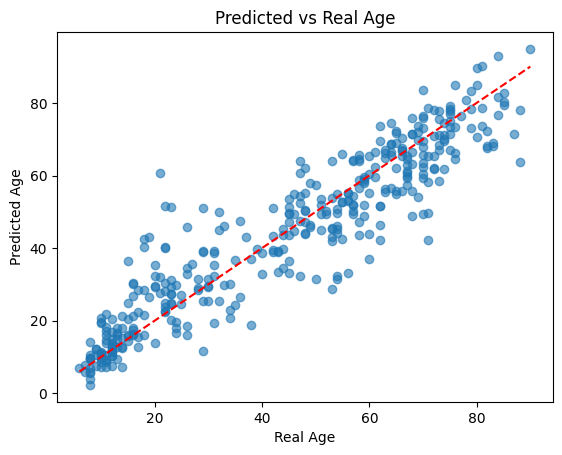

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load the best model saved during training
CNN_model = load_model('/content/drive/MyDrive/best_model.keras')
print("✅ Best model loaded from Drive!")

# Run predictions on the unseen test set
y_pred = CNN_model.predict(X_test_rgb).flatten()

# MAE: average error in years (lower = better)
mae = mean_absolute_error(y_test, y_pred)

# RMSE: penalizes large errors more than MAE (lower = better)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²: how well predictions match reality — 1.0 is perfect (higher = better)
r2 = r2_score(y_test, y_pred)

# % of predictions within ±5 years of real age (higher = better)
within5 = np.mean(np.abs(y_test - y_pred) <= 5) * 100

print("=" * 40)
print("       MODEL ACCURACY REPORT")
print("=" * 40)
print(f"  MAE:                       {mae:.2f} years")
print(f"  RMSE:                      {rmse:.2f} years")
print(f"  R²:                        {r2:.4f}")
print(f"  Accuracy (within ±5 yrs):  {within5:.1f}%")
print("=" * 40)

# Scatter plot: perfect predictions would follow the red line
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age")
plt.show()